In [1]:
import pandas as pd
import numpy as np


In [3]:
df=pd.read_csv("paysim dataset.csv")

In [5]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [9]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [10]:
df.shape

(6362620, 11)

In [13]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [14]:
df['isFraud'].value_counts()


isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [15]:
df['isFraud'].value_counts(normalize=True)

isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64

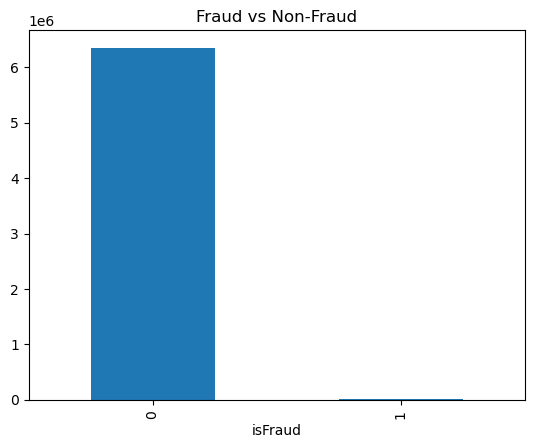

In [16]:
import matplotlib.pyplot as plt

df['isFraud'].value_counts().plot(kind='bar')
plt.title("Fraud vs Non-Fraud")
plt.show()

In [17]:
df.groupby('type')['isFraud'].sum()
df['type'].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

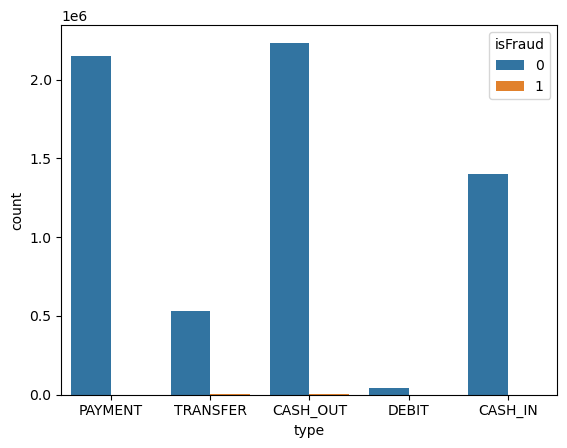

In [18]:
import seaborn as sns

sns.countplot(x='type', hue='isFraud', data=df)
plt.show()

In [19]:
# Drop useless columns
df = df.drop(['nameOrig', 'nameDest'], axis=1)

# Feature Engineering
df['orig_diff'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['dest_diff'] = df['newbalanceDest'] - df['oldbalanceDest']

df['orig_zero'] = (df['oldbalanceOrg'] == 0).astype(int)
df['dest_zero'] = (df['oldbalanceDest'] == 0).astype(int)

# High risk type feature (VERY IMPORTANT)
df['isHighRiskType'] = df['type'].isin(['CASH_OUT', 'TRANSFER']).astype(int)

# Encode categorical
df = pd.get_dummies(df, columns=['type'], drop_first=True)

In [20]:
df

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,orig_diff,dest_diff,orig_zero,dest_zero,isHighRiskType,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.00,160296.36,0.00,0.00,0,0,9839.64,0.00,0,1,0,False,False,True,False
1,1,1864.28,21249.00,19384.72,0.00,0.00,0,0,1864.28,0.00,0,1,0,False,False,True,False
2,1,181.00,181.00,0.00,0.00,0.00,1,0,181.00,0.00,0,1,1,False,False,False,True
3,1,181.00,181.00,0.00,21182.00,0.00,1,0,181.00,-21182.00,0,0,1,True,False,False,False
4,1,11668.14,41554.00,29885.86,0.00,0.00,0,0,11668.14,0.00,0,1,0,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,339682.13,339682.13,0.00,0.00,339682.13,1,0,339682.13,339682.13,0,1,1,True,False,False,False
6362616,743,6311409.28,6311409.28,0.00,0.00,0.00,1,0,6311409.28,0.00,0,1,1,False,False,False,True
6362617,743,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,0,6311409.28,6311409.27,0,0,1,True,False,False,False
6362618,743,850002.52,850002.52,0.00,0.00,0.00,1,0,850002.52,0.00,0,1,1,False,False,False,True


In [21]:
from sklearn.model_selection import train_test_split

X = df.drop('isFraud', axis=1)
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [22]:
fraud = sum(y_train == 1)
normal = sum(y_train == 0)

scale_pos_weight = normal / fraud
print(scale_pos_weight)

773.7482496194825


In [24]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [27]:
y_prob = model.predict_proba(X_test)[:,1]

In [28]:
threshold = 0.7  # try 0.1, 0.2, 0.3, 0.5

y_pred = (y_prob > threshold).astype(int)

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

[[1267867    3014]
 [     17    1626]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.35      0.99      0.52      1643

    accuracy                           1.00   1272524
   macro avg       0.68      0.99      0.76   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC: 0.9996409014090346


In [30]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(X.columns, open("columns.pkl", "wb"))